In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

In [10]:
file_path = "/used_car_market_data.xls"

excel_file = pd.ExcelFile(file_path)
excel_file.sheet_names

['Sheet1', 'raw_data', 'cleaned_data', 'model_summary', 'segment_summary']

In [11]:
df = pd.read_excel(file_path, sheet_name="cleaned_data")

df.head()

,Unnamed: 0,record_id,collection_date,city,make,model,trim,model_year,price_cad,mileage_km,...,generation,notes,analysis_model,segment,vehicle_age,mileage_per_year,powertrain_group,performance_flag,mileage_flag,analysis_include
0,NaN,CIVH_001,2026-07-30,Thornhill,Honda,Civic Hybrid,Sport,2026,36160,9328,...,11th Generation,$332 below market; exterior gray,Civic Hybrid,Mainstream Compact,0,NaN,Hybrid,No,Normal,Yes
1,NaN,CIVH_002,2026-07-30,Whitby,Honda,Civic Hybrid,Sport,2025,32900,39312,...,11th Generation,$568 above market; exterior gray,Civic Hybrid,Mainstream Compact,1,39312.0,Hybrid,No,Normal,Yes
2,NaN,CIVH_003,2026-07-30,Brantford,Honda,Civic Hybrid,Sport,2026,36580,1316,...,11th Generation,$723 below market; mileage too low; service lo...,Civic Hybrid,Mainstream Compact,0,NaN,Hybrid,No,Very Low,Yes
3,NaN,CIVH_004,2026-07-30,Richmond Hill,Honda,Civic Hybrid,Sport,2025,31500,17782,...,11th Generation,"$1,861 below market; Certified Pre-Owned; exte...",Civic Hybrid,Mainstream Compact,1,17782.0,Hybrid,No,Normal,Yes
4,NaN,CIVH_005,2026-07-30,Richmond Hill,Honda,Civic Hybrid,Sport,2025,31909,6466,...,11th Generation,"$2,002 below market; Certified Pre-Owned; exte...",Civic Hybrid,Mainstream Compact,1,6466.0,Hybrid,No,Normal,Yes


In [12]:
df.shape

(203, 26)

In [13]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

df.shape

(203, 25)

In [14]:
df.head()

,record_id,collection_date,city,make,model,trim,model_year,price_cad,mileage_km,body_style,...,generation,notes,analysis_model,segment,vehicle_age,mileage_per_year,powertrain_group,performance_flag,mileage_flag,analysis_include
0,CIVH_001,2026-07-30,Thornhill,Honda,Civic Hybrid,Sport,2026,36160,9328,Sedan,...,11th Generation,$332 below market; exterior gray,Civic Hybrid,Mainstream Compact,0,NaN,Hybrid,No,Normal,Yes
1,CIVH_002,2026-07-30,Whitby,Honda,Civic Hybrid,Sport,2025,32900,39312,Sedan,...,11th Generation,$568 above market; exterior gray,Civic Hybrid,Mainstream Compact,1,39312.0,Hybrid,No,Normal,Yes
2,CIVH_003,2026-07-30,Brantford,Honda,Civic Hybrid,Sport,2026,36580,1316,Sedan,...,11th Generation,$723 below market; mileage too low; service lo...,Civic Hybrid,Mainstream Compact,0,NaN,Hybrid,No,Very Low,Yes
3,CIVH_004,2026-07-30,Richmond Hill,Honda,Civic Hybrid,Sport,2025,31500,17782,Sedan,...,11th Generation,"$1,861 below market; Certified Pre-Owned; exte...",Civic Hybrid,Mainstream Compact,1,17782.0,Hybrid,No,Normal,Yes
4,CIVH_005,2026-07-30,Richmond Hill,Honda,Civic Hybrid,Sport,2025,31909,6466,Sedan,...,11th Generation,"$2,002 below market; Certified Pre-Owned; exte...",Civic Hybrid,Mainstream Compact,1,6466.0,Hybrid,No,Normal,Yes


In [15]:
check_columns = [
    "price_cad",
    "mileage_km",
    "vehicle_age",
    "mileage_per_year",
    "analysis_model",
    "segment",
    "analysis_include"
]

df[check_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_cad         203 non-null    int64  
 1   mileage_km        203 non-null    int64  
 2   vehicle_age       203 non-null    int64  
 3   mileage_per_year  191 non-null    float64
 4   analysis_model    203 non-null    object 
 5   segment           203 non-null    object 
 6   analysis_include  203 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.2+ KB


In [16]:
df[check_columns].isna().sum()

,0
price_cad,0
mileage_km,0
vehicle_age,0
mileage_per_year,12
analysis_model,0
segment,0
analysis_include,0


In [17]:
df["analysis_include"].value_counts(dropna=False)

,count
analysis_include,
Yes,203


In [18]:
analysis_df = df[
    (df["analysis_include"] == "Yes") &
    (df["analysis_model"] != "AMG C43")
].copy()

analysis_df.shape

(202, 25)

In [21]:
analysis_df["mileage_5k"] = analysis_df["mileage_km"] / 5000

analysis_df[
    ["price_cad", "mileage_km", "mileage_10k", "vehicle_age"]
].head()

,price_cad,mileage_km,mileage_10k,vehicle_age
0,36160,9328,1.8656,0
1,32900,39312,7.8624,1
2,36580,1316,0.2632,0
3,31500,17782,3.5564,1
4,31909,6466,1.2932,1


In [22]:
model_1 = smf.ols(
    formula="price_cad ~ mileage_5k + vehicle_age",
    data=analysis_df
).fit()

model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              price_cad   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     42.28
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           4.97e-16
Time:                        21:56:59   Log-Likelihood:                -2068.5
No. Observations:                 202   AIC:                             4143.
Df Residuals:                     199   BIC:                             4153.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3.888e+04    940.580     41.340      0.000     3.7e+04    4.07e+04
mileage_5k   -506.5549     70.652     -7.170      0.000    -645.877    -367.233
vehicle_age  -273.9294    350.493     -0.782      0.435    -965.087     417.228
==============================================================================
Omnibus:                        9.531   Durbin-Watson:                   0.739
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               12.047
Skew:                           0.346   Prob(JB):                      0.00242
Kurtosis:                       3.976   Cond. No.                         27.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
model_2 = smf.ols(
    formula="price_cad ~ mileage_5k + vehicle_age + C(segment)",
    data=analysis_df
).fit()

model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              price_cad   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     83.70
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           2.08e-41
Time:                        22:01:03   Log-Likelihood:                -2004.0
No. Observations:                 202   AIC:                             4018.
Df Residuals:                     197   BIC:                             4034.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         4.746e+04    978.520     48.502      0.000    4.55e+04    4.94e+04
C(segment)[T.Mainstream Compact] -1.445e+04   1092.380    -13.232      0.000   -1.66e+04   -1.23e+04
C(segment)[T.Mainstream Midsize] -6089.8425    850.885     -7.157      0.000   -7767.856   -4411.829
mileage_5k                        -353.7663     53.078     -6.665      0.000    -458.441    -249.092
vehicle_age                      -2282.7270    299.112     -7.632      0.000   -2872.599   -1692.855
==============================================================================
Omnibus:                        1.804   Durbin-Watson:                   0.937
Prob(Omnibus):                  0.406   Jarque-Bera (JB):                1.551
Skew:                           0.050   Prob(JB):                        0.461
Kurtosis:                       3.417   Cond. No.                         57.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
model_3 = smf.ols(
    formula="""
        price_cad ~ mileage_5k + vehicle_age
        + C(analysis_model, Treatment(reference="Sonata N Line"))
    """,
    data=analysis_df
).fit()

model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              price_cad   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     72.57
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           2.89e-69
Time:                        22:03:36   Log-Likelihood:                -1909.9
No. Observations:                 202   AIC:                             3852.
Df Residuals:                     186   BIC:                             3905.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=============================================================================================================================================
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  3.686e+04   1244.979     29.608      0.000    3.44e+04    3.93e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.3 Series]        1.277e+04   1473.137      8.668      0.000    9862.888    1.57e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A4]              7033.6493   1492.184      4.714      0.000    4089.868    9977.431
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A5 Sportback]    1.318e+04   1570.997      8.387      0.000    1.01e+04    1.63e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Accord Hybrid]   7856.1239   1390.071      5.652      0.000    5113.792    1.06e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.C300]            1.542e+04   1525.886     10.109      0.000    1.24e+04    1.84e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Camry Hybrid]    1.019e+04   1520.374      6.704      0.000    7193.661    1.32e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Civic Hybrid]     -47.1935   1422.328     -0.033      0.974   -2853.163    2758.776
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra]        -6618.8458   1460.419     -4.532      0.000   -9499.961   -3737.730
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra N Line] -5792.9284   2582.447     -2.243      0.026   -1.09e+04    -698.277
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.0T]        6328.4503   2261.606      2.798      0.006    1866.754    1.08e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.5T]        1.128e+04   2222.170      5.074      0.000    6891.118    1.57e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 3.3T]        1.388e+04   1509.921      9.196      0.000    1.09e+04    1.69e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Sonata]         -1799.6175   1447.718     -1.243      0.215   -4655.676    1056.441
mileage_5k                                                                 -373.8662     34.923    -10.705      0.000    -442.763    -304.970
vehicle_age                                                               -2564.9933    224.152    -11.443      0.000   -3007.200   -2122.787
==============================================================================
Omnibus:                       59.719   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              242.418
Skew:                           1.098   Prob(JB):                     2.29e-53
Kurtosis:                       7.897   Cond. No.                    

In [25]:
model_3_robust = smf.ols(
    formula="""
        price_cad ~ mileage_5k + vehicle_age
        + C(analysis_model, Treatment(reference="Sonata N Line"))
    """,
    data=analysis_df
).fit(cov_type="HC3")

model_3_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              price_cad   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     45.24
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           7.89e-54
Time:                        22:07:38   Log-Likelihood:                -1909.9
No. Observations:                 202   AIC:                             3852.
Df Residuals:                     186   BIC:                             3905.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
=============================================================================================================================================
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  3.686e+04    807.685     45.638      0.000    3.53e+04    3.84e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.3 Series]        1.277e+04   1894.915      6.739      0.000    9055.129    1.65e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A4]              7033.6493   1377.476      5.106      0.000    4333.846    9733.453
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A5 Sportback]    1.318e+04   1081.144     12.187      0.000    1.11e+04    1.53e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Accord Hybrid]   7856.1239    824.099      9.533      0.000    6240.919    9471.328
C(analysis_model, Treatment(reference="Sonata N Line"))[T.C300]            1.542e+04   1444.365     10.679      0.000    1.26e+04    1.83e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Camry Hybrid]    1.019e+04   1311.251      7.774      0.000    7623.049    1.28e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Civic Hybrid]     -47.1935    785.289     -0.060      0.952   -1586.332    1491.945
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra]        -6618.8458   1270.435     -5.210      0.000   -9108.853   -4128.838
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra N Line] -5792.9284   2800.510     -2.069      0.039   -1.13e+04    -304.029
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.0T]        6328.4503   1326.206      4.772      0.000    3729.134    8927.767
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.5T]        1.128e+04   2151.816      5.240      0.000    7057.534    1.55e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 3.3T]        1.388e+04   1275.628     10.885      0.000    1.14e+04    1.64e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Sonata]         -1799.6175    899.160     -2.001      0.045   -3561.939     -37.296
mileage_5k                                                                 -373.8662     43.422     -8.610      0.000    -458.972    -288.761
vehicle_age                                                               -2564.9933    321.326     -7.983      0.000   -3194.780   -1935.207
==============================================================================
Omnibus:                       59.719   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              242.418
Skew:                           1.098   Prob(JB):                     2.29e-53
Kurtosis:                       7.897   Cond. No.                    

In [26]:
scenario = pd.DataFrame({
    "analysis_model": sorted(analysis_df["analysis_model"].unique()),
    "mileage_5k": 12,
    "vehicle_age": 3
})

scenario.head()

,analysis_model,mileage_5k,vehicle_age
0,3 Series,12,3
1,A4,12,3
2,A5 Sportback,12,3
3,Accord Hybrid,12,3
4,C300,12,3


In [27]:
prediction = model_3_robust.get_prediction(scenario).summary_frame(alpha=0.05)

scenario_results = pd.concat(
    [scenario.reset_index(drop=True), prediction.reset_index(drop=True)],
    axis=1
)

scenario_results[
    ["analysis_model", "mean", "mean_ci_lower", "mean_ci_upper"]
].sort_values("mean", ascending=False)

,analysis_model,mean,mean_ci_lower,mean_ci_upper
4,C300,40104.054721,38041.480675,42166.628766
11,G70 3.3T,38564.123158,36697.127617,40431.118698
2,A5 Sportback,37855.412441,37136.704256,38574.120627
0,3 Series,37448.542187,34805.030011,40092.054363
10,G70 2.5T,35954.464453,31821.504206,40087.424701
5,Camry Hybrid,34872.503392,33528.457287,36216.549496
3,Accord Hybrid,32535.573044,31461.886356,33609.259733
1,A4,31713.098418,29939.810882,33486.385955
9,G70 2.0T,31007.899503,29085.647339,32930.151668
13,Sonata N Line,24679.449160,22954.737766,26404.160553


In [28]:
model_support = (
    analysis_df
    .groupby("analysis_model")
    .agg(
        sample_size=("record_id", "count"),
        minimum_age=("vehicle_age", "min"),
        maximum_age=("vehicle_age", "max"),
        minimum_mileage=("mileage_km", "min"),
        maximum_mileage=("mileage_km", "max")
    )
    .reset_index()
)

model_support

,analysis_model,sample_size,minimum_age,maximum_age,minimum_mileage,maximum_mileage
0,3 Series,22,1,6,370,146574
1,A4,22,2,6,1975,107222
2,A5 Sportback,14,2,6,27837,115327
3,Accord Hybrid,24,0,3,402,144795
4,C300,14,1,4,5468,127233
5,Camry Hybrid,21,2,6,26300,215125
6,Civic Hybrid,20,0,1,1316,153500
7,Elantra,18,1,4,16600,203621
8,Elantra N Line,2,1,2,21259,51679
9,G70 2.0T,3,3,4,16444,60274


In [29]:
scenario_check = scenario_results.merge(
    model_support,
    on="analysis_model",
    how="left"
)

scenario_check[
    [
        "analysis_model",
        "mean",
        "sample_size",
        "minimum_age",
        "maximum_age",
        "minimum_mileage",
        "maximum_mileage"
    ]
].sort_values("mean", ascending=False)

,analysis_model,mean,sample_size,minimum_age,maximum_age,minimum_mileage,maximum_mileage
4,C300,40104.054721,14,1,4,5468,127233
11,G70 3.3T,38564.123158,15,1,4,13310,111157
2,A5 Sportback,37855.412441,14,2,6,27837,115327
0,3 Series,37448.542187,22,1,6,370,146574
10,G70 2.5T,35954.464453,3,0,2,9945,41791
5,Camry Hybrid,34872.503392,21,2,6,26300,215125
3,Accord Hybrid,32535.573044,24,0,3,402,144795
1,A4,31713.098418,22,2,6,1975,107222
9,G70 2.0T,31007.899503,3,3,4,16444,60274
13,Sonata N Line,24679.449160,7,0,2,7300,67444


In [30]:
scenario_check["age_supported"] = (
    (scenario_check["minimum_age"] <= 3) &
    (scenario_check["maximum_age"] >= 3)
)

scenario_check["mileage_supported"] = (
    (scenario_check["minimum_mileage"] <= 60000) &
    (scenario_check["maximum_mileage"] >= 60000)
)

scenario_check["support_status"] = np.where(
    scenario_check["age_supported"] &
    scenario_check["mileage_supported"],
    "Within observed range",
    "Extrapolated"
)

scenario_check[
    [
        "analysis_model",
        "mean",
        "sample_size",
        "age_supported",
        "mileage_supported",
        "support_status"
    ]
].sort_values("mean", ascending=False)

,analysis_model,mean,sample_size,age_supported,mileage_supported,support_status
4,C300,40104.054721,14,True,True,Within observed range
11,G70 3.3T,38564.123158,15,True,True,Within observed range
2,A5 Sportback,37855.412441,14,True,True,Within observed range
0,3 Series,37448.542187,22,True,True,Within observed range
10,G70 2.5T,35954.464453,3,False,False,Extrapolated
5,Camry Hybrid,34872.503392,21,True,True,Within observed range
3,Accord Hybrid,32535.573044,24,True,True,Within observed range
1,A4,31713.098418,22,True,True,Within observed range
9,G70 2.0T,31007.899503,3,True,True,Within observed range
13,Sonata N Line,24679.449160,7,False,True,Extrapolated


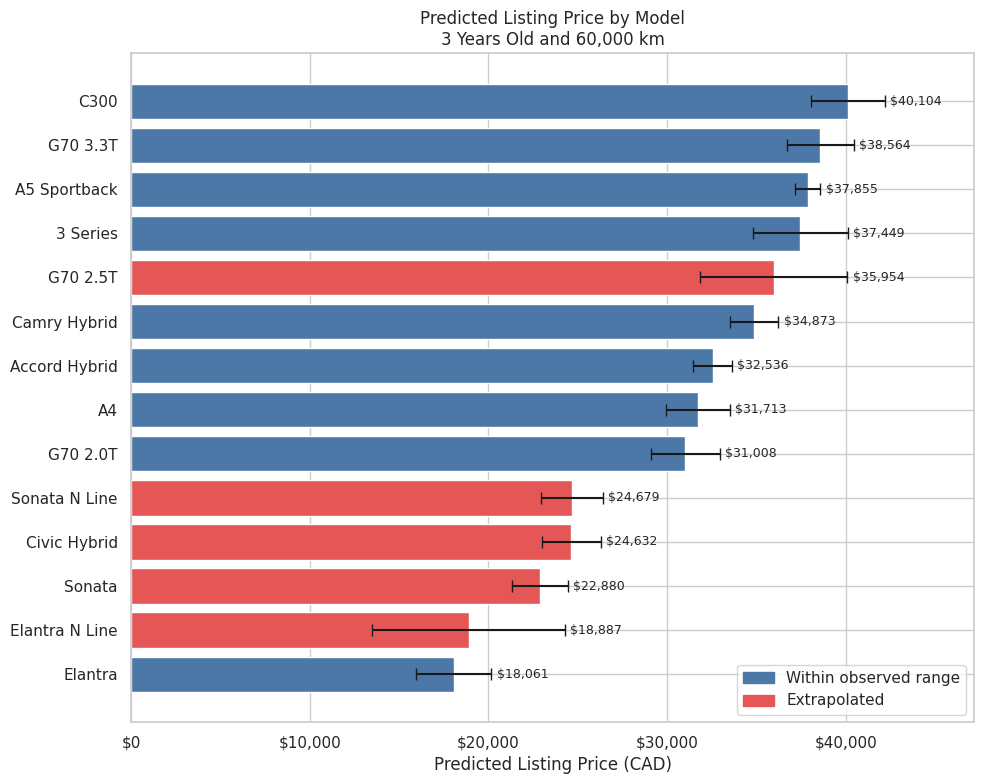

In [33]:
from matplotlib.ticker import StrMethodFormatter
import matplotlib.patches as mpatches

plot_df = scenario_check.sort_values("mean", ascending=True)

colors = np.where(
    plot_df["support_status"] == "Within observed range",
    "#4C78A8",
    "#E45756"
)

lower_error = plot_df["mean"] - plot_df["mean_ci_lower"]
upper_error = plot_df["mean_ci_upper"] - plot_df["mean"]

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["analysis_model"],
    plot_df["mean"],
    xerr=[lower_error, upper_error],
    color=colors,
    capsize=4
)

plt.xlabel("Predicted Listing Price (CAD)")
plt.ylabel("")
plt.title("Predicted Listing Price by Model\n3 Years Old and 60,000 km")

plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.xlim(
    0,
    plot_df["mean_ci_upper"].max() + 5000
)

label_df = plot_df.reset_index(drop=True)

for index, row in label_df.iterrows():
    plt.text(
        row["mean_ci_upper"] + 300,
        index,
        f"${row['mean']:,.0f}",
        va="center",
        fontsize=9
    )

blue_patch = mpatches.Patch(
    color="#4C78A8",
    label="Within observed range"
)

red_patch = mpatches.Patch(
    color="#E45756",
    label="Extrapolated"
)

plt.legend(handles=[blue_patch, red_patch], loc="lower right")
plt.tight_layout()
plt.savefig(
    "predicted_listing_price_3yr_60000km.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Regression Diagnostics

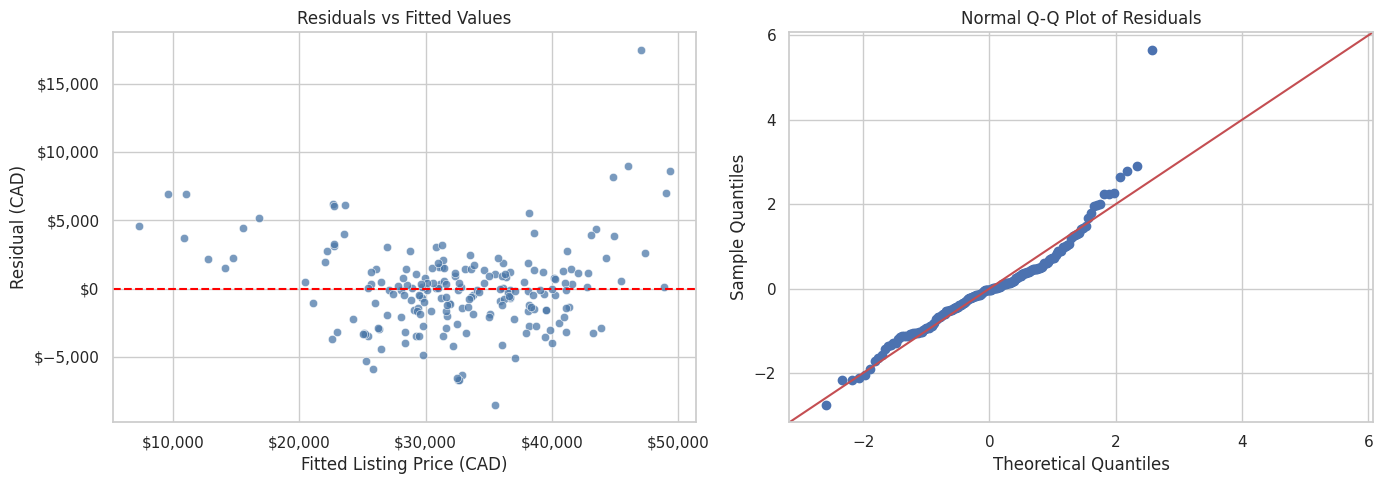

In [34]:
import statsmodels.api as sm

fitted_values = model_3_robust.fittedvalues
residuals = model_3_robust.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.scatterplot(
    x=fitted_values,
    y=residuals,
    ax=axes[0],
    color="#4C78A8",
    alpha=0.75
)

axes[0].axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Listing Price (CAD)")
axes[0].set_ylabel("Residual (CAD)")

axes[0].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

axes[0].yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

# Q-Q Plot
sm.qqplot(
    residuals,
    line="45",
    fit=True,
    ax=axes[1]
)

axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.tight_layout()

plt.savefig(
    "regression_diagnostic_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
diagnostic_df = analysis_df.copy()

diagnostic_df["fitted_price"] = model_3.fittedvalues
diagnostic_df["residual"] = model_3.resid
diagnostic_df["absolute_residual"] = diagnostic_df["residual"].abs()

influence = model_3.get_influence()
diagnostic_df["cooks_distance"] = influence.cooks_distance[0]

diagnostic_df.sort_values(
    "absolute_residual",
    ascending=False
)[
    [
        "record_id",
        "analysis_model",
        "model_year",
        "trim",
        "price_cad",
        "mileage_km",
        "vehicle_age",
        "fitted_price",
        "residual",
        "cooks_distance"
    ]
].head(10)

,record_id,analysis_model,model_year,trim,price_cad,mileage_km,vehicle_age,fitted_price,residual,cooks_distance
156,BMW3_012,3 Series,2025,330i xDrive,64495,370,1,47037.257533,17457.742467,0.159857
146,BMW3_002,3 Series,2025,330i xDrive,54988,14000,1,46018.098193,8969.901807,0.040767
197,MBCC_010,C300,2025,C300 4MATIC,57900,5468,1,49311.576060,8588.423940,0.046272
186,G70_020,G70 3.3T,2023,3.3T Sport,26995,101230,3,35481.222232,-8486.222232,0.038705
165,BMW3_021,3 Series,2025,330i xDrive,52999,29646,1,44848.195989,8150.804011,0.033467
195,MBCC_008,C300,2025,C300 4MATIC,55995,9680,1,48996.631148,6998.368852,0.030488
24,ELAN_005,Elantra,2022,Ultimate,17998,119462,4,11049.443219,6948.556781,0.023500
25,ELAN_006,Elantra,2022,Ultimate,16488,139101,4,9580.971445,6907.028555,0.025505
118,AUD4_010,A4,2024,Komfort 45 TFSI,26000,81377,2,32679.664091,-6679.664091,0.022294
117,AUD4_009,A4,2024,Komfort 45 TFSI,25848,83417,2,32527.126670,-6679.126670,0.022650


In [38]:
cooks_threshold = 4 / len(diagnostic_df)

influential_vehicles = diagnostic_df[
    diagnostic_df["cooks_distance"] > cooks_threshold
].copy()

print(f"Cook's distance threshold: {cooks_threshold:.4f}")
print(f"Number of influential vehicles: {len(influential_vehicles)}")

influential_vehicles[
    [
        "record_id",
        "analysis_model",
        "price_cad",
        "mileage_km",
        "vehicle_age",
        "residual",
        "cooks_distance"
    ]
].sort_values(
    "cooks_distance",
    ascending=False
)

Cook's distance threshold: 0.0198
Number of influential vehicles: 16


,record_id,analysis_model,price_cad,mileage_km,vehicle_age,residual,cooks_distance
156,BMW3_012,3 Series,64495,370,1,17457.742467,0.159857
197,MBCC_010,C300,57900,5468,1,8588.423940,0.046272
35,ELAN_016,Elantra N Line,23988,51679,2,1914.297743,0.044504
28,ELAN_009,Elantra N Line,24999,21259,1,-1914.297743,0.044504
181,G70_015,G70 2.5T,36821,41791,2,-3060.003835,0.042803
146,BMW3_002,3 Series,54988,14000,1,8969.901807,0.040767
186,G70_020,G70 3.3T,26995,101230,3,-8486.222232,0.038705
165,BMW3_021,3 Series,52999,29646,1,8150.804011,0.033467
182,G70_016,G70 2.5T,50021,9945,0,2628.780680,0.032542
195,MBCC_008,C300,55995,9680,1,6998.368852,0.030488


In [39]:
sensitivity_df = analysis_df[
    analysis_df["record_id"] != "BMW3_012"
].copy()

model_3_sensitivity = smf.ols(
    formula="""
        price_cad ~ mileage_5k + vehicle_age
        + C(analysis_model, Treatment(reference="Sonata N Line"))
    """,
    data=sensitivity_df
).fit(cov_type="HC3")

model_3_sensitivity.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              price_cad   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     48.07
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.44e-55
Time:                        23:16:52   Log-Likelihood:                -1882.1
No. Observations:                 201   AIC:                             3796.
Df Residuals:                     185   BIC:                             3849.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
=============================================================================================================================================
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                   3.66e+04    789.563     46.354      0.000    3.51e+04    3.81e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.3 Series]        1.147e+04   1564.705      7.328      0.000    8399.535    1.45e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A4]              6555.3096   1315.238      4.984      0.000    3977.490    9133.129
C(analysis_model, Treatment(reference="Sonata N Line"))[T.A5 Sportback]     1.27e+04   1024.725     12.395      0.000    1.07e+04    1.47e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Accord Hybrid]   7727.0109    826.951      9.344      0.000    6106.217    9347.805
C(analysis_model, Treatment(reference="Sonata N Line"))[T.C300]            1.512e+04   1466.804     10.307      0.000    1.22e+04     1.8e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Camry Hybrid]    9616.2316   1211.042      7.940      0.000    7242.633     1.2e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Civic Hybrid]      78.1888    787.256      0.099      0.921   -1464.804    1621.181
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra]        -6857.1522   1206.014     -5.686      0.000   -9220.897   -4493.408
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Elantra N Line] -5844.9629   2651.673     -2.204      0.028    -1.1e+04    -647.779
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.0T]        5975.4436   1250.000      4.780      0.000    3525.488    8425.399
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 2.5T]        1.127e+04   2278.142      4.948      0.000    6806.560    1.57e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.G70 3.3T]        1.357e+04   1274.369     10.646      0.000    1.11e+04    1.61e+04
C(analysis_model, Treatment(reference="Sonata N Line"))[T.Sonata]         -1810.6279    900.164     -2.011      0.044   -3574.917     -46.339
mileage_5k                                                                 -363.2547     40.126     -9.053      0.000    -441.900    -284.610
vehicle_age                                                               -2407.8924    295.813     -8.140      0.000   -2987.676   -1828.109
==============================================================================
Omnibus:                       18.649   Durbin-Watson:                   1.888
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.808
Skew:                           0.516   Prob(JB):                     2.04e-07
Kurtosis:                       4.616   Cond. No.                    

In [40]:
coefficient_comparison = pd.DataFrame({
    "Original Model": model_3_robust.params,
    "Without BMW3_012": model_3_sensitivity.params
})

coefficient_comparison["Difference"] = (
    coefficient_comparison["Without BMW3_012"]
    - coefficient_comparison["Original Model"]
)

coefficient_comparison.round(2)

,Original Model,Without BMW3_012,Difference
Intercept,36860.82,36599.81,-261.02
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.3 Series]",12769.09,11466.30,-1302.79
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.A4]",7033.65,6555.31,-478.34
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.A5 Sportback]",13175.96,12701.19,-474.77
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.Accord Hybrid]",7856.12,7727.01,-129.11
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.C300]",15424.61,15118.30,-306.31
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.Camry Hybrid]",10193.05,9616.23,-576.82
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.Civic Hybrid]",-47.19,78.19,125.38
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.Elantra]",-6618.85,-6857.15,-238.31
"C(analysis_model, Treatment(reference=""Sonata N Line""))[T.Elantra N Line]",-5792.93,-5844.96,-52.03


In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Original Model",
        "Without BMW3_012"
    ],
    "Observations": [
        int(model_3_robust.nobs),
        int(model_3_sensitivity.nobs)
    ],
    "R_squared": [
        model_3_robust.rsquared,
        model_3_sensitivity.rsquared
    ],
    "Adjusted_R_squared": [
        model_3_robust.rsquared_adj,
        model_3_sensitivity.rsquared_adj
    ]
})

model_comparison.round(3)

,Model,Observations,R_squared,Adjusted_R_squared
0,Original Model,202,0.854,0.842
1,Without BMW3_012,201,0.869,0.858


In [43]:
model_1_robust = smf.ols(
    formula="price_cad ~ mileage_5k + vehicle_age",
    data=analysis_df
).fit(cov_type="HC3")

model_2_robust = smf.ols(
    formula="price_cad ~ mileage_5k + vehicle_age + C(segment)",
    data=analysis_df
).fit(cov_type="HC3")

In [44]:
model_fit_summary = pd.DataFrame({
    "Model": [
        "Model 1: Mileage and Age",
        "Model 2: Add Segment",
        "Model 3: Add Vehicle Model"
    ],
    "Observations": [
        int(model_1_robust.nobs),
        int(model_2_robust.nobs),
        int(model_3_robust.nobs)
    ],
    "R_squared": [
        model_1_robust.rsquared,
        model_2_robust.rsquared,
        model_3_robust.rsquared
    ],
    "Adjusted_R_squared": [
        model_1_robust.rsquared_adj,
        model_2_robust.rsquared_adj,
        model_3_robust.rsquared_adj
    ],
    "Mileage_effect_per_5000km": [
        model_1_robust.params["mileage_5k"],
        model_2_robust.params["mileage_5k"],
        model_3_robust.params["mileage_5k"]
    ],
    "Vehicle_age_effect": [
        model_1_robust.params["vehicle_age"],
        model_2_robust.params["vehicle_age"],
        model_3_robust.params["vehicle_age"]
    ]
})

model_fit_summary.round(2)

,Model,Observations,R_squared,Adjusted_R_squared,Mileage_effect_per_5000km,Vehicle_age_effect
0,Model 1: Mileage and Age,202,0.30,0.29,-506.55,-273.93
1,Model 2: Add Segment,202,0.63,0.62,-353.77,-2282.73
2,Model 3: Add Vehicle Model,202,0.85,0.84,-373.87,-2564.99


In [45]:
model_fit_summary.to_csv(
    "model_fit_summary.csv",
    index=False
)

scenario_check.to_csv(
    "personal_purchase_scenario_results.csv",
    index=False
)